<a href="https://colab.research.google.com/github/amy165/Insurance-Risk-Pricing-Analysis-End-to-End-Project/blob/main/notebooks/01_eda_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Install the Kaggle API client
!pip install kaggle

In [2]:
# Load Kaggle credentials from Colab secrets
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

print("Kaggle API client setup complete.")

Kaggle API client setup complete.


In [3]:
# Example: Download a public dataset (e.g., Iris dataset)
# !kaggle datasets download -d uciml/iris

# Replace with the actual dataset you want to download:
!kaggle datasets download -d imtkaggleteam/vehicle-insurance-data

# Example of unzipping the downloaded file (if it's a zip file)
!unzip vehicle-insurance-data.zip

print("Dataset download command executed. Check the output for file names.")

Dataset URL: https://www.kaggle.com/datasets/imtkaggleteam/vehicle-insurance-data
License(s): Attribution 4.0 International (CC BY 4.0)
100% 11.0M/11.0M [00:00<00:00, 214MB/s]

Archive:  vehicle-insurance-data.zip
  inflating: motor_data11-14lats.csv  
  inflating: motor_data14-2018.csv   
Dataset download command executed. Check the output for file names.


In [4]:
import pandas as pd
data11_14_df=pd.read_csv('motor_data11-14lats.csv')
data14_18_df=pd.read_csv('motor_data14-2018.csv')

In [5]:
data11_14_df.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-13,07-AUG-14,08,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-12,07-AUG-13,08,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-11,07-AUG-12,08,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-JUL-11,07-AUG-11,08,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-13,07-AUG-14,08,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43


In [6]:
data14_18_df.head()

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
0,0,08-AUG-17,07-AUG-18,08,1202,519755.22,5097.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
1,0,08-AUG-16,07-AUG-17,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
2,0,08-AUG-15,07-AUG-16,08,1202,519755.22,6556.52,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
3,0,08-AUG-14,07-AUG-15,08,1202,519755.22,5102.83,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,NaN
4,0,08-AUG-17,07-AUG-18,08,1202,1400000.00,13304.87,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,NaN


In [7]:
data11_14_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293537 entries, 0 to 293536
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                293537 non-null  int64  
 1   INSR_BEGIN         293537 non-null  object 
 2   INSR_END           293537 non-null  object 
 3   EFFECTIVE_YR       293536 non-null  object 
 4   INSR_TYPE          293537 non-null  int64  
 5   INSURED_VALUE      293537 non-null  float64
 6   PREMIUM            293529 non-null  float64
 7   OBJECT_ID          293537 non-null  int64  
 8   PROD_YEAR          293431 non-null  float64
 9   SEATS_NUM          293397 non-null  float64
 10  CARRYING_CAPACITY  212172 non-null  float64
 11  TYPE_VEHICLE       293537 non-null  object 
 12  CCM_TON            293535 non-null  float64
 13  MAKE               293537 non-null  object 
 14  USAGE              293537 non-null  object 
 15  CLAIM_PAID         22373 non-null   float64
dtypes:

In [8]:
data14_18_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508499 entries, 0 to 508498
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                508499 non-null  int64  
 1   INSR_BEGIN         508499 non-null  object 
 2   INSR_END           508499 non-null  object 
 3   EFFECTIVE_YR       508496 non-null  object 
 4   INSR_TYPE          508499 non-null  int64  
 5   INSURED_VALUE      508499 non-null  float64
 6   PREMIUM            508486 non-null  float64
 7   OBJECT_ID          508499 non-null  int64  
 8   PROD_YEAR          508436 non-null  float64
 9   SEATS_NUM          508404 non-null  float64
 10  CARRYING_CAPACITY  391665 non-null  float64
 11  TYPE_VEHICLE       508499 non-null  object 
 12  CCM_TON            508493 non-null  float64
 13  MAKE               508494 non-null  object 
 14  USAGE              508499 non-null  object 
 15  CLAIM_PAID         37772 non-null   float64
dtypes:

In [9]:
data11_14_df.columns

Index(['SEX', 'INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'INSR_TYPE',
       'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID', 'PROD_YEAR', 'SEATS_NUM',
       'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
       'CLAIM_PAID'],
      dtype='object')

In [10]:
data11_14_df['TYPE_VEHICLE'].unique()

array(['Pick-up', 'Station Wagones', 'Truck', 'Bus', 'Automobile',
       'Tanker', 'Trailers and semitrailers', 'Motor-cycle', 'Tractor',
       'Special construction', 'Trade plates'], dtype=object)

In [11]:
data11_14_df['USAGE'].unique()

array(['Own Goods', 'Private', 'General Cartage',
       'Fare Paying Passengers', 'Taxi', 'Car Hires', 'Own service',
       'Agricultural Own Farm', 'Special Construction', 'Others',
       'Learnes', 'Ambulance', 'Agricultural Any Farm', 'Fire fighting'],
      dtype=object)

In [13]:
full_df=pd.concat([data11_14_df, data14_18_df], ignore_index=True)

In [14]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802036 entries, 0 to 802035
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                802036 non-null  int64  
 1   INSR_BEGIN         802036 non-null  object 
 2   INSR_END           802036 non-null  object 
 3   EFFECTIVE_YR       802032 non-null  object 
 4   INSR_TYPE          802036 non-null  int64  
 5   INSURED_VALUE      802036 non-null  float64
 6   PREMIUM            802015 non-null  float64
 7   OBJECT_ID          802036 non-null  int64  
 8   PROD_YEAR          801867 non-null  float64
 9   SEATS_NUM          801801 non-null  float64
 10  CARRYING_CAPACITY  603837 non-null  float64
 11  TYPE_VEHICLE       802036 non-null  object 
 12  CCM_TON            802028 non-null  float64
 13  MAKE               802031 non-null  object 
 14  USAGE              802036 non-null  object 
 15  CLAIM_PAID         60145 non-null   float64
dtypes:

In [15]:
full_df.describe()

,SEX,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,CLAIM_PAID
count,802036.000000,802036.000000,8.020360e+05,8.020150e+05,8.020360e+05,801867.000000,801801.000000,603837.000000,802028.000000,6.014500e+04
mean,0.567092,1201.742123,5.091294e+05,7.406987e+03,5.000453e+09,2004.533970,6.130357,497.877618,3172.698129,2.564802e+05
std,0.644430,0.440322,9.017833e+05,1.352456e+04,3.444165e+05,10.227981,13.403486,3861.218481,3445.455114,1.495336e+06
min,0.000000,1201.000000,0.000000e+00,0.000000e+00,5.000018e+09,1950.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,1201.000000,0.000000e+00,7.557000e+02,5.000160e+09,2000.000000,1.000000,0.000000,200.000000,1.350000e+04
50%,0.000000,1202.000000,1.800000e+05,3.376550e+03,5.000380e+09,2008.000000,4.000000,6.000000,2494.000000,3.463352e+04
75%,1.000000,1202.000000,7.300000e+05,9.643270e+03,5.000718e+09,2012.000000,4.000000,35.000000,4164.000000,1.338690e+05
max,2.000000,1204.000000,2.500000e+08,7.581230e+06,5.001351e+09,2018.000000,199.000000,1000000.000000,20000.000000,1.524458e+08


In [16]:
full_df['CLAIM_PAID'] = full_df['CLAIM_PAID'].fillna(0)

In [17]:
full_df[full_df['PROD_YEAR'].isnull()]

,SEX,INSR_BEGIN,INSR_END,EFFECTIVE_YR,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID
67747,1,10-AUG-13,09-AUG-14,58,1204,50000.0,576.9,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0
67748,1,10-AUG-12,09-AUG-13,58,1204,50000.0,576.9,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0
67749,1,10-AUG-11,09-AUG-12,58,1204,0.0,641.0,5000089917,NaN,NaN,NaN,Automobile,0.0,1982,Others,0.0
80229,0,08-AUG-13,07-AUG-14,98,1204,0.0,576.9,5000083743,NaN,NaN,NaN,Automobile,4323.0,TOYOTA,Others,0.0
80230,0,08-AUG-12,07-AUG-13,98,1204,0.0,576.9,5000083743,NaN,NaN,NaN,Automobile,4323.0,TOYOTA,Others,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
764832,0,17-AUG-17,16-AUG-18,17,1204,100000.0,1498.5,5001102319,NaN,NaN,NaN,Automobile,0.0,TOYOTA,Others,0.0
769371,0,16-SEP-17,15-SEP-18,17,1204,200000.0,3201.0,5001128173,NaN,4.0,NaN,Automobile,1500.0,TOYOTA,Private,0.0
790271,1,27-FEB-18,26-FEB-19,18,1204,50000.0,1282.0,5001210421,NaN,NaN,NaN,Automobile,0.0,ISUZU,Others,0.0
790658,0,29-MAR-18,28-MAR-19,18,1204,0.0,641.0,5001228172,NaN,NaN,NaN,Truck,0.0,ISUZU,General Cartage,0.0


In [20]:
invalid_cases = full_df[
    (full_df['PREMIUM'] == 0) | full_df['PREMIUM'].isna() | full_df['PROD_YEAR'].isna()
].copy()

In [21]:
full_df = full_df.dropna(subset=['PREMIUM','PROD_YEAR'])

In [22]:
full_df = full_df[full_df['PREMIUM'] > 0].copy()

In [23]:
full_df['TYPE_VEHICLE'] = full_df['TYPE_VEHICLE'].fillna('Unknown')
full_df['MAKE'] = full_df['MAKE'].fillna('Unknown')
full_df['USAGE'] = full_df['USAGE'].fillna('Unknown')

In [24]:
full_df['SEATS_NUM'] = full_df.groupby('TYPE_VEHICLE')['SEATS_NUM'].transform(
    lambda x: x.fillna(x.median())
)

full_df['CARRYING_CAPACITY'] = full_df.groupby('TYPE_VEHICLE')['CARRYING_CAPACITY'].transform(
    lambda x: x.fillna(x.median())
)

full_df['CCM_TON'] = full_df.groupby('TYPE_VEHICLE')['CCM_TON'].transform(
    lambda x: x.fillna(x.median())
)

In [25]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801817 entries, 0 to 802035
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                801817 non-null  int64  
 1   INSR_BEGIN         801817 non-null  object 
 2   INSR_END           801817 non-null  object 
 3   EFFECTIVE_YR       801813 non-null  object 
 4   INSR_TYPE          801817 non-null  int64  
 5   INSURED_VALUE      801817 non-null  float64
 6   PREMIUM            801817 non-null  float64
 7   OBJECT_ID          801817 non-null  int64  
 8   PROD_YEAR          801817 non-null  float64
 9   SEATS_NUM          801817 non-null  float64
 10  CARRYING_CAPACITY  801817 non-null  float64
 11  TYPE_VEHICLE       801817 non-null  object 
 12  CCM_TON            801817 non-null  float64
 13  MAKE               801817 non-null  object 
 14  USAGE              801817 non-null  object 
 15  CLAIM_PAID         801817 non-null  float64
dtypes: floa

In [26]:
full_df['EFFECTIVE_YR'].unique()

array(['08', '11', '01', '12', '13', '07', '61', '06', '14', '74', '10',
       '09', '97', '89', '72', '63', '95', '79', '91', '80', '26', '73',
       '05', '96', '94', '5/', '92', '99', '84', '75', '00', '18', '03',
       '28', '87', '02', '85', '59', '82', '76', '04', '86', '27', '45',
       '32', '57', '-1', '46', '55', '37', '65', '50', '34', '67', '81',
       '19', '15', '30', '56', '77', '47', '38', '31', '16', '33', '93',
       '24', '98', '78', '88', '90', '54', '35', '20', '48', '44', '42',
       '52', '41', '6-', '40', '49', '39', '5B', '53', '3B', '60', '71',
       '70', '2B', '58', '25', '23', '43', '22', '-7', '51', '66', '7B',
       '68', '21', '1B', '36', '62', '17', '64', '-B', '/B', '83', '69',
       '29', '/2', '6A', '8B', 'EN', '-2', '-6', '-8', '4A', '0-', '-9',
       '1A', '8R', '-3', 'SR', '1-', '0B', '9B', 'MO', nan, '1S', 'BS',
       '1R', 'RS', 'SS', '1K', '1M', '6B', '7-', 'IN', '2A', '/1', '0A',
       '/A', '4B', '1C', '/0', '5A', 'EA', '3A', '5C

In [27]:
full_df['EFFECTIVE_YR'].dtype
full_df['EFFECTIVE_YR'].sample(20, random_state=42)
full_df[['INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'PROD_YEAR']].sample(20, random_state=42)

,INSR_BEGIN,INSR_END,EFFECTIVE_YR,PROD_YEAR
369255,07-AUG-16,06-AUG-17,11,2010.0
422801,08-AUG-14,07-AUG-15,11,1988.0
431404,08-JUL-14,07-JUL-15,13,1986.0
16229,04-OCT-11,25-JAN-12,20,1985.0
192927,01-JAN-14,31-DEC-14,70,1990.0
150897,20-FEB-14,19-FEB-15,11,2007.0
319684,08-JUL-17,07-JUL-18,11,2009.0
6403,08-JUL-11,07-AUG-11,02,1996.0
735377,07-DEC-16,06-DEC-17,16,2015.0
63524,08-JUL-13,07-JUL-14,10,2003.0


not found a consistent relation between PROD_YEAR and INSR_BEGIN and since there are also categoric values i decided to drop that column

In [28]:
full_df = full_df.drop('EFFECTIVE_YR', axis=1)

In [29]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801817 entries, 0 to 802035
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                801817 non-null  int64  
 1   INSR_BEGIN         801817 non-null  object 
 2   INSR_END           801817 non-null  object 
 3   INSR_TYPE          801817 non-null  int64  
 4   INSURED_VALUE      801817 non-null  float64
 5   PREMIUM            801817 non-null  float64
 6   OBJECT_ID          801817 non-null  int64  
 7   PROD_YEAR          801817 non-null  float64
 8   SEATS_NUM          801817 non-null  float64
 9   CARRYING_CAPACITY  801817 non-null  float64
 10  TYPE_VEHICLE       801817 non-null  object 
 11  CCM_TON            801817 non-null  float64
 12  MAKE               801817 non-null  object 
 13  USAGE              801817 non-null  object 
 14  CLAIM_PAID         801817 non-null  float64
dtypes: float64(7), int64(3), object(5)
memory usage: 97.9+ M

array([[<Axes: title={'center': 'SEX'}>,
        <Axes: title={'center': 'INSR_TYPE'}>,
        <Axes: title={'center': 'INSURED_VALUE'}>],
       [<Axes: title={'center': 'PREMIUM'}>,
        <Axes: title={'center': 'OBJECT_ID'}>,
        <Axes: title={'center': 'PROD_YEAR'}>],
       [<Axes: title={'center': 'SEATS_NUM'}>,
        <Axes: title={'center': 'CARRYING_CAPACITY'}>,
        <Axes: title={'center': 'CCM_TON'}>],
       [<Axes: title={'center': 'CLAIM_PAID'}>, <Axes: >, <Axes: >]],
      dtype=object)

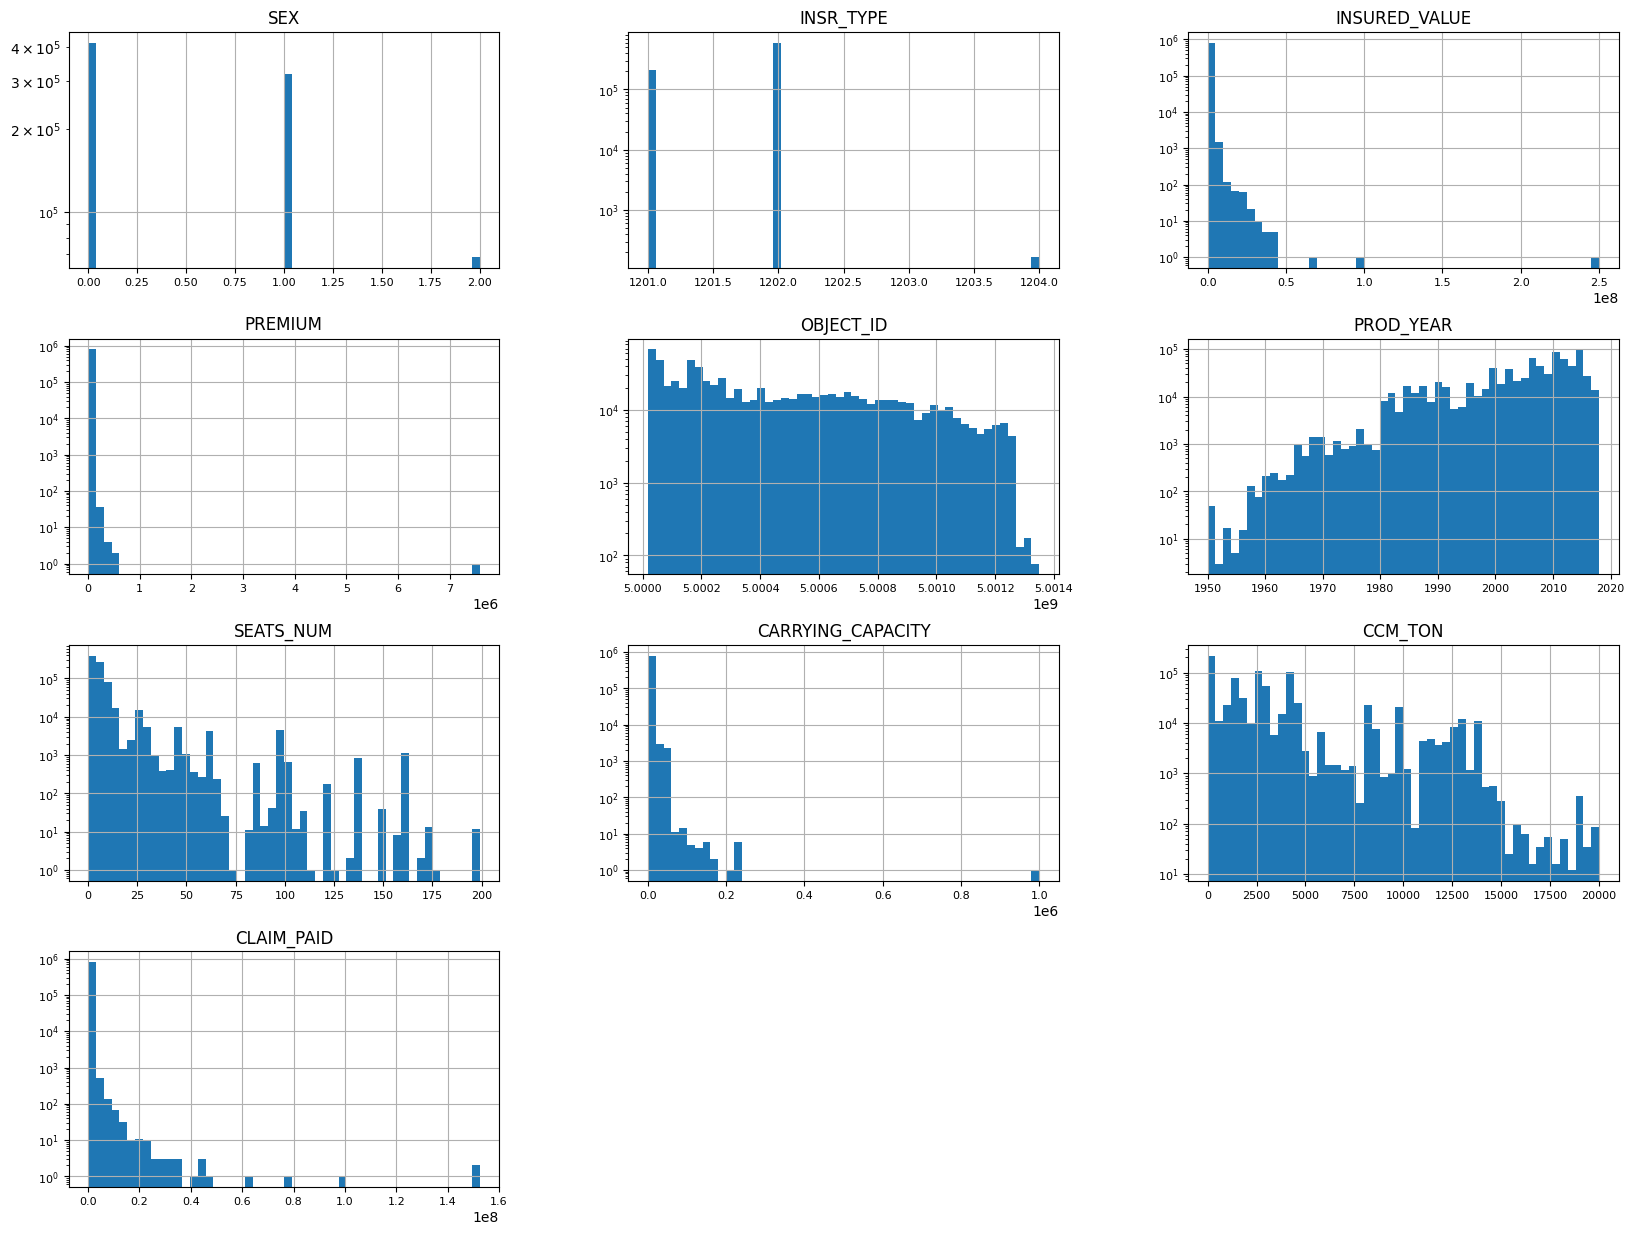

In [30]:
full_df.hist(figsize=(20,15), bins=50, xlabelsize=8, ylabelsize=8, log=True)

In [31]:
#frecuency of claims per policy
(full_df['CLAIM_PAID']>0).mean()

np.float64(0.07495226466887082)

In [32]:
full_df['INSR_BEGIN'] = pd.to_datetime(
    full_df['INSR_BEGIN'],
    format='%d-%b-%y',
    errors='coerce'
)

full_df['INSR_END'] = pd.to_datetime(
    full_df['INSR_END'],
    format='%d-%b-%y',
    errors='coerce'
)

full_df['begin_year'] = full_df['INSR_BEGIN'].dt.year

In [33]:
full_df['policy_duration'] = (full_df['INSR_END'] - full_df['INSR_BEGIN']).dt.days
full_df['has_claim'] = (full_df['CLAIM_PAID'] > 0).astype(int)
full_df['loss_ratio'] = full_df['CLAIM_PAID'] / full_df['PREMIUM']
full_df['vehicle_age'] = full_df['begin_year'] - full_df['PROD_YEAR']

In [34]:
full_df[['INSR_BEGIN', 'INSR_END']].head()

,INSR_BEGIN,INSR_END
0,2013-08-08,2014-08-07
1,2012-08-08,2013-08-07
2,2011-08-08,2012-08-07
3,2011-07-08,2011-08-07
4,2013-08-08,2014-08-07


In [35]:
full_df['INSR_BEGIN'].isna().sum()

np.int64(0)

In [36]:
full_df['INSR_BEGIN'].min(), full_df['INSR_BEGIN'].max()

(Timestamp('2011-07-01 00:00:00'), Timestamp('2018-06-30 00:00:00'))

In [37]:
full_df['INSR_END'].isna().sum()

np.int64(0)

In [38]:
full_df['policy_duration'] = (full_df['INSR_END'] - full_df['INSR_BEGIN']).dt.days
full_df['policy_duration'].describe()

,policy_duration
count,801817.000000
mean,351.348570
std,59.056727
min,0.000000
25%,364.000000
50%,364.000000
75%,364.000000
max,523.000000


In [39]:
(full_df['policy_duration']==0).sum()

np.int64(190)

In [40]:
full_df[full_df['policy_duration'] > 365]['policy_duration'].value_counts().head(10)

,count
policy_duration,
374,6
375,4
366,4
371,3
453,3
523,2
368,2
382,2
385,2


In [41]:
full_df[full_df['policy_duration'] > 365]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,begin_year,policy_duration,has_claim,loss_ratio,vehicle_age
2770,1,2014-03-19,2015-03-25,1202,0.00,3551.200,5000023232,2007.0,27.0,27.00,Bus,3920.0,HIGHER,Fare Paying Passengers,0.00,2014,371,0,0.000000,7.0
3512,1,2013-02-18,2014-05-17,1202,70000.00,1944.860,5000024879,1981.0,0.0,150.00,Trailers and semitrailers,0.0,VIBERTI,General Cartage,0.00,2013,453,0,0.000000,32.0
6458,0,2014-03-20,2015-03-29,1202,514828.50,3546.200,5000023349,2007.0,27.0,27.00,Bus,3920.0,HIGER BUS,Fare Paying Passengers,0.00,2014,374,0,0.000000,7.0
10767,1,2014-03-19,2015-03-25,1202,0.00,3546.200,5000023231,2007.0,27.0,27.00,Bus,3920.0,HIGHER,Fare Paying Passengers,0.00,2014,371,0,0.000000,7.0
11974,0,2014-03-20,2015-03-29,1202,514828.52,3546.200,5000023347,2007.0,27.0,27.00,Bus,3920.0,HIGER BUS,Fare Paying Passengers,0.00,2014,374,0,0.000000,7.0
45926,0,2014-03-20,2015-03-29,1202,514828.52,3551.200,5000042307,2007.0,27.0,27.00,Bus,3920.0,HIGHER,Fare Paying Passengers,0.00,2014,374,0,0.000000,7.0
58599,2,2014-03-19,2015-04-08,1202,300000.00,4613.840,5000074731,2000.0,0.0,230.50,Trailers and semitrailers,0.0,MESFIN,General Cartage,343390.08,2014,385,1,74.426092,14.0
58604,2,2014-03-19,2015-04-08,1202,1200000.00,20864.360,5000074726,1999.0,1.0,165.00,Truck,13798.0,IVECO,General Cartage,343390.08,2014,385,1,16.458213,15.0
93054,1,2011-11-08,2013-04-14,1202,530000.00,15522.380,5000150143,1990.0,0.0,163.00,Truck,11600.0,DAF,General Cartage,0.00,2011,523,0,0.000000,21.0
93057,1,2011-11-08,2013-04-14,1202,80000.00,1211.840,5000150144,2004.0,0.0,230.00,Trailers and semitrailers,0.0,TRAILER,General Cartage,0.00,2011,523,0,0.000000,7.0


In [42]:
full_df[full_df['policy_duration'] ==0]

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,CLAIM_PAID,begin_year,policy_duration,has_claim,loss_ratio,vehicle_age
14595,0,2014-05-25,2014-05-25,1202,0.0,790.63,5000019397,2013.0,2.0,2.0,Automobile,2500.0,PEUGEOT,Own service,0.0,2014,0,0,0.0,1.0
48019,0,2014-05-25,2014-05-25,1202,0.0,575.00,5000069490,2013.0,2.0,2.0,Automobile,1000.0,FIAT,Own service,0.0,2014,0,0,0.0,1.0
50374,0,2014-05-25,2014-05-25,1202,0.0,661.25,5000069371,2013.0,2.0,2.0,Automobile,1600.0,TOYOTA,Own service,0.0,2014,0,0,0.0,1.0
50375,0,2014-05-25,2014-05-25,1202,0.0,661.25,5000069380,2013.0,2.0,2.0,Automobile,1600.0,VOLKS WAGON,Own service,0.0,2014,0,0,0.0,1.0
50377,0,2014-05-25,2014-05-25,1202,0.0,575.00,5000069424,2013.0,0.0,2.0,Automobile,1000.0,FIAT,Own service,0.0,2014,0,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698763,0,2016-04-17,2016-04-17,1202,0.0,631.55,5000894948,2000.0,0.0,2.0,Automobile,0.0,TOYOTA,Others,0.0,2016,0,0,0.0,16.0
698764,0,2016-04-17,2016-04-17,1202,0.0,631.55,5000894953,2000.0,0.0,2.0,Automobile,2400.0,WAZ,Others,0.0,2016,0,0,0.0,16.0
698765,0,2016-04-17,2016-04-17,1202,0.0,631.55,5000894958,2000.0,0.0,2.0,Automobile,0.0,TOYOTA,Others,0.0,2016,0,0,0.0,16.0
698766,0,2016-04-17,2016-04-17,1202,0.0,631.55,5000894962,2010.0,0.0,2.0,Automobile,0.0,VOLKS WAGON,Others,0.0,2016,0,0,0.0,6.0


In [43]:
invalid_cases = pd.concat([
    invalid_cases,
    full_df[full_df['policy_duration'] == 0]
], ignore_index=True)

In [44]:
full_df = full_df[full_df['policy_duration'] > 0]

In [45]:
full_df['vehicle_age'].describe()

,vehicle_age
count,801627.000000
mean,10.141641
std,9.858830
min,-7.000000
25%,2.000000
50%,7.000000
75%,15.000000
max,68.000000


In [46]:
(full_df['vehicle_age']<0).sum()

np.int64(2988)

In [47]:
neg = full_df[full_df['vehicle_age'] < 0]

neg.shape[0] / full_df.shape[0]

0.003727419360874821

In [48]:
neg['vehicle_age'].value_counts()

,count
vehicle_age,
-1.0,2384
-2.0,227
-3.0,178
-4.0,109
-5.0,61
-6.0,25
-7.0,4


vehicle_age < -3 considered data inconsistence. -1 and -2 could be with the new released cars

In [49]:
invalid_cases = pd.concat([
    invalid_cases,
    full_df[full_df['vehicle_age'] <= -3]
], ignore_index=True)

In [50]:
full_df = full_df[full_df['vehicle_age'] > -3]
full_df['vehicle_age'] = full_df['vehicle_age'].clip(lower=0)

In [51]:
full_df['vehicle_age'].describe()

,vehicle_age
count,801250.000000
mean,10.151768
std,9.852593
min,0.000000
25%,2.000000
50%,7.000000
75%,15.000000
max,68.000000


In [52]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801250 entries, 0 to 802035
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   SEX                801250 non-null  int64         
 1   INSR_BEGIN         801250 non-null  datetime64[ns]
 2   INSR_END           801250 non-null  datetime64[ns]
 3   INSR_TYPE          801250 non-null  int64         
 4   INSURED_VALUE      801250 non-null  float64       
 5   PREMIUM            801250 non-null  float64       
 6   OBJECT_ID          801250 non-null  int64         
 7   PROD_YEAR          801250 non-null  float64       
 8   SEATS_NUM          801250 non-null  float64       
 9   CARRYING_CAPACITY  801250 non-null  float64       
 10  TYPE_VEHICLE       801250 non-null  object        
 11  CCM_TON            801250 non-null  float64       
 12  MAKE               801250 non-null  object        
 13  USAGE              801250 non-null  object       

In [54]:
full_df.duplicated().sum()

np.int64(303)

In [55]:
full_df = full_df.drop_duplicates()

In [56]:
full_df['loss_ratio'] = full_df['CLAIM_PAID'] / full_df['PREMIUM']

In [57]:
full_df['loss_ratio'].describe()

,loss_ratio
count,800947.000000
mean,1.699767
std,27.332765
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5572.701918


In [58]:
full_df.to_csv('cleaned_vehicle_insurance.csv', index=False)